2-Exploratory Data Analysis

understand the data visually before running any statisical test

2-1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sys, os

sys.path.append(os.path.join(os.getcwd(), '..'))
from src.utils import plot_conversion_rates, group_sizes, confidence_interval, conversion_rate

df = pd.read_csv('../data/marketing_AB_clean.csv')
print(f"Loaded {len(df):,} rows")

Loaded 588,101 rows


2-2 Group sizes- check for imbalance

In [2]:
sizes = group_sizes(df)
print(sizes)
ratio = sizes.max() / sizes.min()
print(f"\nImbalance ratio: {ratio:.2f}x  {'⚠ Check this' if ratio > 3 else '✓ Acceptable'}") 

test group
ad     564577
psa     23524
Name: n_users, dtype: int64

Imbalance ratio: 24.00x  ⚠ Check this


2-3 Conversion rates per group

In [3]:
rates = conversion_rate(df)
print(rates.apply(lambda x: f"{x*100:.3f}%"))
print(f"\nAbsolute difference: {abs(rates.diff().iloc[-1])*100:.3f} pp")

test group
ad     2.555%
psa    1.785%
Name: converted, dtype: object

Absolute difference: 0.769 pp


2-4 Bar chart with 95% confidence intervals

In [4]:
# build CI for each group
groups = df['test group'].unique()
cis = {}
for g in groups:
    sub = df[df['test group'] == g]
    successes = sub['converted'].sum()
    nobs = len(sub)
    cis[g] = confidence_interval(successes, nobs)

rates_dict = rates.to_dict()
plot_conversion_rates(rates_dict, cis, save_path='../outputs/plots/conversion_rates.png')

Saved --> ../outputs/plots/conversion_rates.png


<Figure size 700x500 with 1 Axes>

2-5 Ad exposure distribution

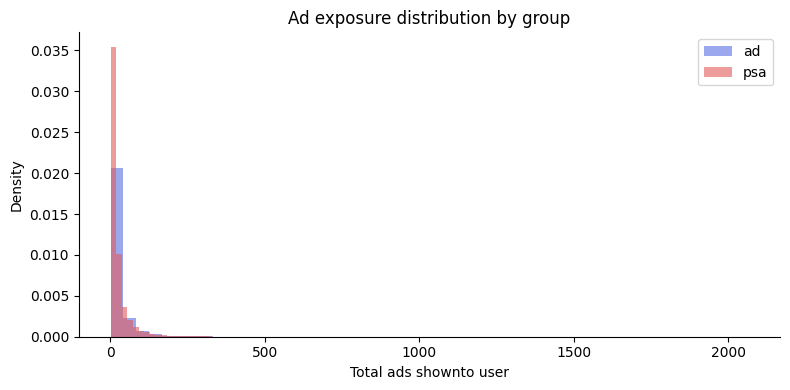


Median ads shown:
test group
ad     13.0
psa    12.0
Name: total ads, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for g, color in zip(df['test group'].unique(), ['#5B6EE1', '#E15B5B']):
    sub = df[df['test group'] == g]['total ads']
    ax.hist(sub, bins=50, alpha=0.6, label=g, color=color, density=True)

ax.set_xlabel('Total ads shownto user')
ax.set_ylabel('Density')
ax.set_title('Ad exposure distribution by group')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/plots/ad_exposure.png', dpi=150)
plt.show()

print("\nMedian ads shown:")
print(df.groupby('test group')['total ads'].median())



2-6 Conversion rate over time (novelty effect check)

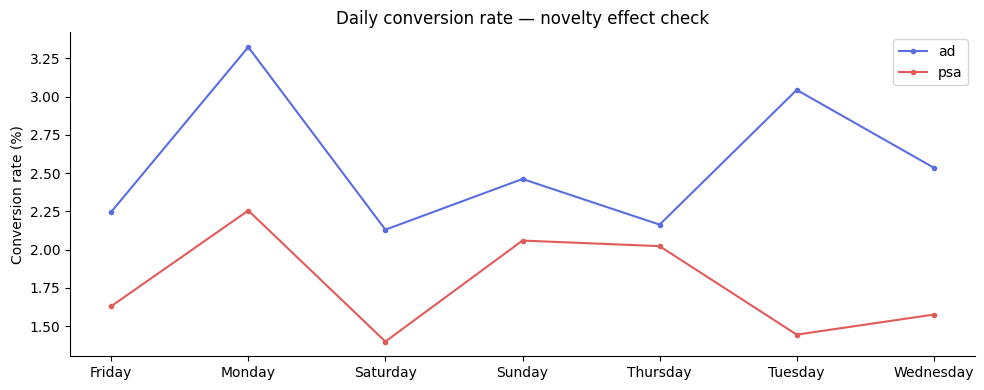

In [6]:
if 'most ads day' in df.columns:
    daily = df.groupby(['most ads day', 'test group'])['converted'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    for g, color in zip(df['test group'].unique(), ['#5B6EE1', '#E15B5B']):
        sub = daily[daily['test group'] == g]
        ax.plot(sub['most ads day'], sub['converted'] * 100, label=g, color=color, marker='o', markersize=3)
    ax.set_ylabel('Conversion rate (%)')
    ax.set_title('Daily conversion rate — novelty effect check')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/plots/time_trend.png', dpi=150)
    plt.show()
else:
    print("No time column found — skip novelty check.")